# Undercomplete Linear 오토인코더로 PCA 구현하기

In [1]:
import sys
import sklearn
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [4]:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "autoencoders"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

In [5]:
def save_fig(fig_id, tight_layout=True, fig_extension='png', resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
def plot_image(image):
    plt.imshow(image, cmap='binary')
    plt.axis("off")

In [7]:
np.random.seed(4)
def generate_3d_data(m, w1=0.1, w2=0.3, noise=0.1): 
    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
    data[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
    data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * np.random.randn(m)
    return data

X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0, keepdims=0)

In [8]:
X_train.shape

(60, 3)

In [9]:
encoder = keras.models.Sequential([keras.layers.Dense(2,input_shape=[3])]) # 3개를 2개로 변환
decoder = keras.models.Sequential([keras.layers.Dense(3,input_shape=[2])]) # 2개를 3개로 변환
autoencoder = keras.models.Sequential([encoder, decoder])

autoencoder.compile(loss='mse', optimizer=keras.optimizers.SGD(lr=1.5))
history = autoencoder.fit(X_train, X_train, epochs=20)

Epoch 1/20



2/2 [==============================] - 0s 13ms/step - loss: 0.7605
Epoch 2/20
2/2 [==============================] - 0s 4ms/step - loss: 0.7347
Epoch 3/20
2/2 [==============================] - 0s 3ms/step - loss: 0.7100
Epoch 4/20
2/2 [==============================] - 0s 4ms/step - loss: 0.6884
Epoch 5/20
2/2 [==============================] - 0s 4ms/step - loss: 0.6670
Epoch 6/20
2/2 [==============================] - 0s 3ms/step - loss: 0.6475
Epoch 7/20
2/2 [==============================] - 0s 4ms/step - loss: 0.6288
Epoch 8/20
2/2 [==============================] - 0s 5ms/step - loss: 0.6119
Epoch 9/20
2/2 [==============================] - 0s 4ms/step - loss: 0.5956
Epoch 10/20
2/2 [==============================] - 0s 5ms/step - loss: 0.5803
Epoch 11/20
2/2 [==============================] - 0s 5ms/step - loss: 0.5658
Epoch 12/20
2/2 [==============================] - 0s 5ms/step - loss: 0.5523
Epoch 13/20
2/2 [==============================] - 0s 4ms/step - loss: 0.5395
Epoch

In [10]:
codings = encoder.predict(X_train)

2/2 [==============================] - 0s 3ms/step


In [11]:
codings.shape

(60, 2)

Saving figure linear_autoencoder_pca_plot


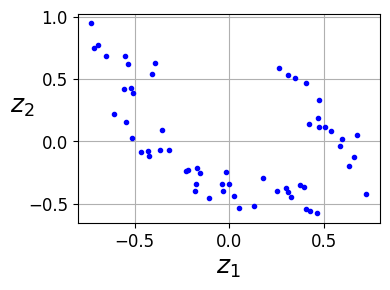

In [13]:
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:,1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)
save_fig("linear_autoencoder_pca_plot")
plt.show()

# Stacked 오토인코더

In [14]:
import sys
import sklearn
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

In [18]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# 스케일링
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255

# 학습, 검증 데이터 분리
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

### SELU(Scaled ELU)
- ELU(Exponential Linear Unit, 지수 선형 유닛) 활성화 함수의 변종
- 완전 연결 층만 쌓아서 신경망을 만들고 모든 은닉층이 SELU 활성화 함수를 사용하면 네트워크가 자기 정규화(self normalized)를 할 수 있다.
- 훈련하는 동안 각 층의 출력이 평균 0과 표준편차 1을 유지한다.

In [19]:
tf.random.set_seed(42)
np.random.seed(42)

stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(100, activation='selu'),
    keras.layers.Dense(30, activation='selu')
])
stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation='selu', input_shape=[30]),
    keras.layers.Dense(28*28, activation='sigmoid'),
    keras.layers.Reshape([28,28])
])
stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])

In [20]:
def rounded_accuracy(y_true, y_pred):
    # binary_accuracy(): 이진 분류 문제에서 모델의 예측이 실제 정답과 얼마나 일치하는지 계산하는 함수
    return keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

In [21]:
stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=keras.optimizers.SGD(lr=1.5),
                   metrics=[rounded_accuracy])
history = stacked_ae.fit(X_train, X_train, epochs=20, validation_data=(X_valid, X_valid))

Epoch 1/20



1719/1719 [==============================] - 6s 3ms/step - loss: 0.6610 - rounded_accuracy: 0.5982 - val_loss: 0.6006 - val_rounded_accuracy: 0.6876
Epoch 2/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5411 - rounded_accuracy: 0.7266 - val_loss: 0.5101 - val_rounded_accuracy: 0.7443
Epoch 3/20
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4982 - rounded_accuracy: 0.7531 - val_loss: 0.4930 - val_rounded_accuracy: 0.7585
Epoch 4/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4833 - rounded_accuracy: 0.7686 - val_loss: 0.4777 - val_rounded_accuracy: 0.7745
Epoch 5/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4657 - rounded_accuracy: 0.7849 - val_loss: 0.4577 - val_rounded_accuracy: 0.7905
Epoch 6/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4432 - rounded_accuracy: 0.8014 - val_loss: 0.4334 - val_rounded_accuracy: 0.8083
Epoch 7/20
1719/1719 [=============================

In [22]:
def show_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2,n_images, 1+image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1+n_images + image_index)
        plot_image(reconstructions[image_index])

1/1 [==============================] - 0s 99ms/step
Saving figure reconstruction_plot


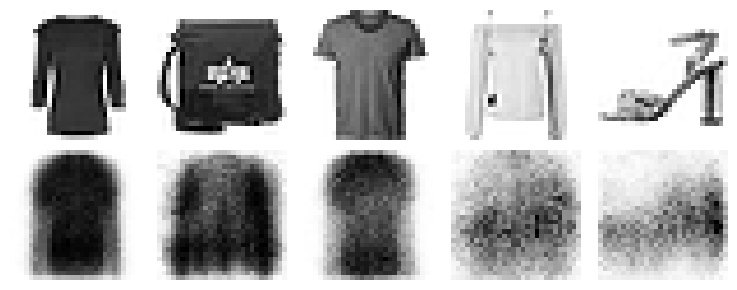

In [23]:
show_reconstructions(stacked_ae)
save_fig("reconstruction_plot")

# 노이즈 제거 예제

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [25]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [26]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis] # 2차원에 한개의 축 추가
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


In [27]:
# 노이즈 추가
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# 노이즈를 더하다 보면 픽셀 값이 0 미만으로 떨어지거나 1을 초과할 수 있습니다. 
# 이미지 데이터의 정상 범위인 0과 1 사이로 값을 강제로 제한(Clipped)해 주는 필수적인 전처리입니다.
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

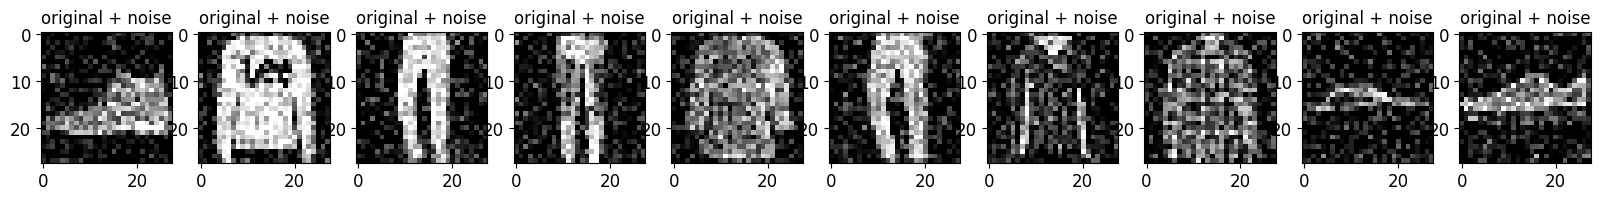

In [28]:
n = 10
plt.figure(figsize=(20,2))
for i in range(n):
    ax = plt.subplot(1,n,i+1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

In [29]:
class Denoise(Model):
    def __init__(self):
        super(Denoise, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28,28,1)),
            layers.Conv2D(16,(3,3), activation='relu', padding='same', strides=2),
            layers.Conv2D(8,(3,3), activation='relu', padding='same', strides=2)])

        self.decoder = tf.keras.Sequential([
            # 전치 합성곱 : 인코더와 반대로 이미지의 크기를 다시 키움
            layers.Conv2DTranspose(8,kernel_size=3, activation='relu', padding='same', strides=2),
            layers.Conv2DTranspose(16,kernel_size=3, activation='relu', padding='same', strides=2),
            layers.Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same')])
    
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [30]:
autoencoder = Denoise()

In [31]:
autoencoder.compile(optimizer='adam', loss = losses.MeanSquaredError())

In [32]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/10
1875/1875 [==============================] - 36s 19ms/step - loss: 0.0175 - val_loss: 0.0093
Epoch 2/10
1875/1875 [==============================] - 33s 17ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 3/10
1875/1875 [==============================] - 34s 18ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 4/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0075 - val_loss: 0.0074
Epoch 5/10
1875/1875 [==============================] - 36s 19ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 6/10
1875/1875 [==============================] - 31s 17ms/step - loss: 0.0070 - val_loss: 0.0070
Epoch 7/10
1875/1875 [==============================] - 35s 19ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 8/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0068 - val_loss: 0.0068
Epoch 9/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 10/10
1875/1875 [==============================] - 30s 16m

In [33]:
autoencoder.encoder.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 16)        160       
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 8)           1160      
                                                                 
Total params: 1320 (5.16 KB)
Trainable params: 1320 (5.16 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
autoencoder.decoder.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_transpose (Conv2DTr  (None, 14, 14, 8)         584       
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 28, 28, 16)        1168      
 Transpose)                                                      
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 1)         145       
                                                                 
Total params: 1897 (7.41 KB)
Trainable params: 1897 (7.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

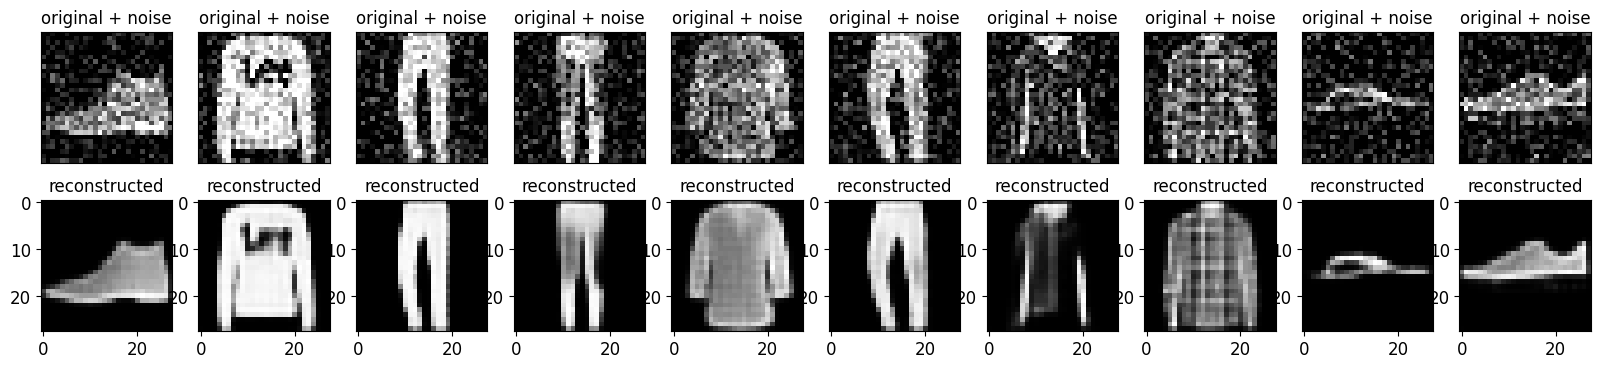

In [36]:
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    bx = plt.subplot(2, n, i+n+1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()